In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp

import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()

In [2]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *

import elements 
import importlib
importlib.reload(elements)



<module 'elements' from '/Users/matteogiacomelli/Documents/Technical_Student/simulation/Knobs in LSS4 SPS/elements.py'>

# CHecking if for a single pass TECA is recording the scattering

In [3]:
TECA = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = - 174e-6 ,              # THIS CRYSTAL IS CHANNELING TOWARDS THE INSIDE OF THE RING!!!
    side="-",
    lattice="strip",
    #jaw = - 35e-3,  #Setting for simulation
    jaw = - 52e-3,  #original setting
    tilt = - 1.23e-3,
    width = 0.8e-3,
    height = 50e-3
    )


## Recording scatterings for multiple turns

In [4]:
line = initialise_lineQ22()

tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

Non-channeled particle lost at element ap.up.mst21774_aper (index 1117) on turn 0
Adjusting ap.up.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21794_a

In [5]:
import optimisers as op
import importlib
importlib.reload(op)

# Set the initial conditions
optLSS4 = horizontal_bumpLSS4(line)

optLSS4.log()
optLSS4.solve()

# Set the initial conditions
optLSS2 = horizontal_bumpLSS2(line, x_target = 0.0394, px_target = 1e-4)

optLSS2.log()
optLSS2.solve()

# bump_closed_orbite = ensure_bump_closed(line)

# bump_closed_orbite.log()

# bump_closed_orbite.step(10)
# bump_closed_orbite.target_status()
# bump_closed_orbite.vary_status()
# knobs_after_closingOrbit = bump_closed_orbite.get_knob_values()
# knobs_after_closingOrbit = bump_closed_orbite.get_knob_values(iteration=0)

tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")

                                             
Optimize - start penalty: 0.5421                            
Matching: model call n. 19 penalty = 2.7566e-15              
Optimize - end penalty:  2.75657e-15                            
                                             
Optimize - start penalty: 2.757e-15                          
Matching: model call n. 21 penalty = 2.7566e-15              
Optimize - end penalty:  2.75657e-15                            
                                             
Optimize - start penalty: 0.3941                            
Matching: model call n. 22 penalty = 1.7989e-13              
Optimize - end penalty:  1.79888e-13                            
                                             
Optimize - start penalty: 1.799e-13                          
Matching: model call n. 24 penalty = 1.7989e-13              
Optimize - end penalty:  1.79888e-13                            


In [6]:
tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS2 = list(line.vars.get_table().rows["kmp.h2.*[0-9]"].name)
bumpersLSS4 = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)

for bumper in bumpersLSS2:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

kmpsh21202 2.3933413057027092e-05
kmplh21431 0.0007837017618755222
kmpnh21732 -0.00012043265222573628
kmplh21995 0.0008602795605444746
kmplh22195 -0.0006035261662459959
kmpsh41402 -0.00036842332510076374
kmplh41658 -0.0006894284584424233
kmplh41994 -0.00063974812540521
kmpsh42198 -0.00017592643298445902


In [7]:
line.env["extr_bump_knob"] = 0.87 ## OPTIMAL FOR EXTRACTION
line.env["x_teca_knob"] = 1.046 ## OPRIMAL FOR EXTRACTION

In [8]:
for bumper in bumpersLSS2:
    line.vv[bumper] = bumper + "_init" + "*  extr_bump_knob"
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.vv[bumper] = bumper + "_init" + "*  x_teca_knob"
    print(bumper, line.vv[bumper])

kmpsh21202 2.082206935961357e-05
kmplh21431 0.0006818205328317043
kmpnh21732 -0.00010477640743639056
kmplh21995 0.0007484432176736929
kmplh22195 -0.0005250677646340164
kmpsh41402 -0.0003853707980553989
kmplh41658 -0.0007211421675307748
kmplh41994 -0.0006691765391738496
kmpsh42198 -0.00018401904890174415


In [9]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)
print(septa_names_with_apertures)

n_part = 500

x_norm   = np.random.normal(loc = 0, scale = 1, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 1, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P

line.build_tracker()

N_EX = 10e-7 # REDUCED NORMALISED EMITTANCE BY A FACTOR 10 AS MASSIMO GIOVANNOZZI SUGGESTED, IT IMPOVES THE EFFICIENY BY 1% !!!

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']

tw_lss2 = tw.rows[:]


line.discard_tracker()

num_turns = 10000

# Define the momentum increment per turn (Δp₀c)
#delta_p0c =  2000e9 / 10 * 23e-6  # Example: 450 GeV over 10 s with 23 μs revolution time
delta_p0c = - 0.6e9 / num_turns  # THE SPS ENERGY CAN GO UP TO 400.6 GeV SO I ASSUME 0.6 GeV DIVIDED BY 100 TURNS

# Create the ReferenceEnergyIncrease element
energy_increase = xt.ReferenceEnergyIncrease(Delta_p0c=delta_p0c)

# Append the energy increase element to the end of the line
line.append_element(energy_increase, name='energy_increase')

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']
The line has collective elements.
In the twiss computation collective elements are replaced by drifts


<Line  at 4605237200>

In [10]:
#PLACING ONLY TWO MONITORS TO SAVE TIME
# Convert Twiss table to DataFrame and set 'name' as index
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

# Remove tracker before inserting new elements
line.discard_tracker()

monitor_tun_number = 100

# INSERT THE FOLLOWING MONITORS IF YOU WANT TO GET THE PHASE SPACE PLOTS AT THE END OF THE SIMULATION

# Insert monitor only at 'TECA.exit'
monitor_teca = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TECA_monitor', element=monitor_teca, index='TECA.exit')
tw_lss2_df.loc['TECA.exit', 'monitors'] = monitor_teca



# # Insert monitor only at 'tpst.21760_entry'
# monitor_tpst = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
# line.insert_element(name='TPST_monitor', element=monitor_tpst, index='tpst.21760_entry')
# tw_lss2_df.loc['tpst.21760_entry', 'monitors'] = monitor_tpst

# # Insert monitor only at tcsm.51932.
# monitor_tcsm = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
# line.insert_element(name='TCSM_monitor', element=monitor_tcsm, index='tcsm.51932.')
# tw_lss2_df.loc['tcsm.51932.', 'monitors'] = monitor_tcsm

line.discard_tracker()
#line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )



# Move the blade_position of 'mst.21794.sep'
element_name = 'mst.21794.sep'
line[element_name].interaction_process.blade_position += 0.002  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21794.sep: 0.0444 m


In [11]:
# Add before tracking
print("Crystal settings:")
print(f"TECA jaw position: {TECA.jaw}")
print(f"TECA tilt: {TECA.tilt}")
#print(f"TECA s-position: {line.get_s_position('extraction.crystal.TECA')}")

print("\nParticle distribution:")
print(f"x range: [{particles.x.min():.2e}, {particles.x.max():.2e}] m")
print(f"px range: [{particles.px.min():.2e}, {particles.px.max():.2e}] rad")

# After tracking, add this diagnostic
print("\nParticle states after tracking:")
print(f"Number of particles: {n_part}")
print(f"Number lost: {np.sum(particles.state < 1)}")
print(f"State values: {np.unique(particles.state)}")

Crystal settings:
TECA jaw position: -0.052
TECA tilt: -0.00123

Particle distribution:
x range: [-1.14e-03, 1.05e-02] m
px range: [-3.11e-05, 2.09e-04] rad

Particle states after tracking:
Number of particles: 500
Number lost: 0
State values: [1]


In [12]:
# line.discard_tracker()
# #line.build_tracker(_context=xo.ContextCpu())
# context = xo.ContextCpu()
# io_buffer = xt.new_io_buffer(capacity=int(1e7))

# TECA.record_scatterings = True

# line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

# impacts = xt.start_internal_logging(elements=[TECA], io_buffer=io_buffer, capacity=io_buffer.capacity)

# line.build_tracker(_context=xo.ContextCpu())

# line.track(
#     particles,
#     num_turns=num_turns,
#     turn_by_turn_monitor=True,
#     # freeze_longitudinal=True,
#     time=True
# )
# if np.any(particles.state < 1):
#     lost_particles = np.where(particles.state < 1)[0]
#     print(f"Particles lost during tracking: {len(lost_particles)}")
# else:
#     print("No particles lost during tracking")
# record = line.time_last_track

# # Sort particles again
# particles.sort(interleave_lost_particles=True)

In [13]:
# First, completely clean up
line.discard_tracker()

# Create context and buffer with explicit settings
context = xo.ContextCpu()
io_buffer = xt.new_io_buffer(capacity=int(1e7))

# Remove TECA if it exists
if "extraction.crystal.TECA" in line.element_names:
    line.remove_element("extraction.crystal.TECA")

# Create a fresh TECA instance
TECA = xc.EverestCrystal(
    length=2e-3,
    material=xc.materials.SiliconCrystal,
    bending_angle=-174e-6,
    side="-",
    lattice="strip",
    jaw=-52e-3,
    tilt=-1.23e-3,
    width=0.8e-3,
    height=50e-3,
)

# Enable recording
TECA.record_scatterings = True

# Insert TECA into line
line.insert_element("extraction.crystal.TECA", TECA, at_s=line.get_table()['s', 'TECA.entry'])

# Verify TECA is in line
print("Verification after insertion:")
print(f"TECA in line: {'extraction.crystal.TECA' in line.element_names}")
print(f"TECA position: {line.get_s_position('extraction.crystal.TECA')}")

# Start logging with element name
impacts = xt.start_internal_logging(
    elements=[TECA],
    io_buffer=io_buffer,
    capacity=io_buffer.capacity
)
#impacts = xt.start_internal_logging(elements=[TECA], io_buffer=io_buffer, capacity=io_buffer.capacity)

# Build tracker
line.build_tracker(_context=context)

# Final verification
print("\nFinal setup verification:")
print(f"TECA recording enabled: {TECA.record_scatterings}")
# Note: impacts does not have an 'elements' attribute.
# If you want to check what was logged, inspect the logger setup or the impacts DataFrame after tracking.

# Track with explicit context
line.track(
    particles,
    num_turns=num_turns,
    turn_by_turn_monitor=True
)

# Check impacts immediately
df = impacts.to_pandas()
print(f"\nImpacts dataframe shape: {df.shape if not df.empty else 'Empty'}")

Slicing line:   0%|          | 0/4618 [00:00<?, ?it/s]

Verification after insertion:
TECA in line: True
TECA position: 4020.8939

Final setup verification:
TECA recording enabled: True

Impacts dataframe shape: (723, 31)


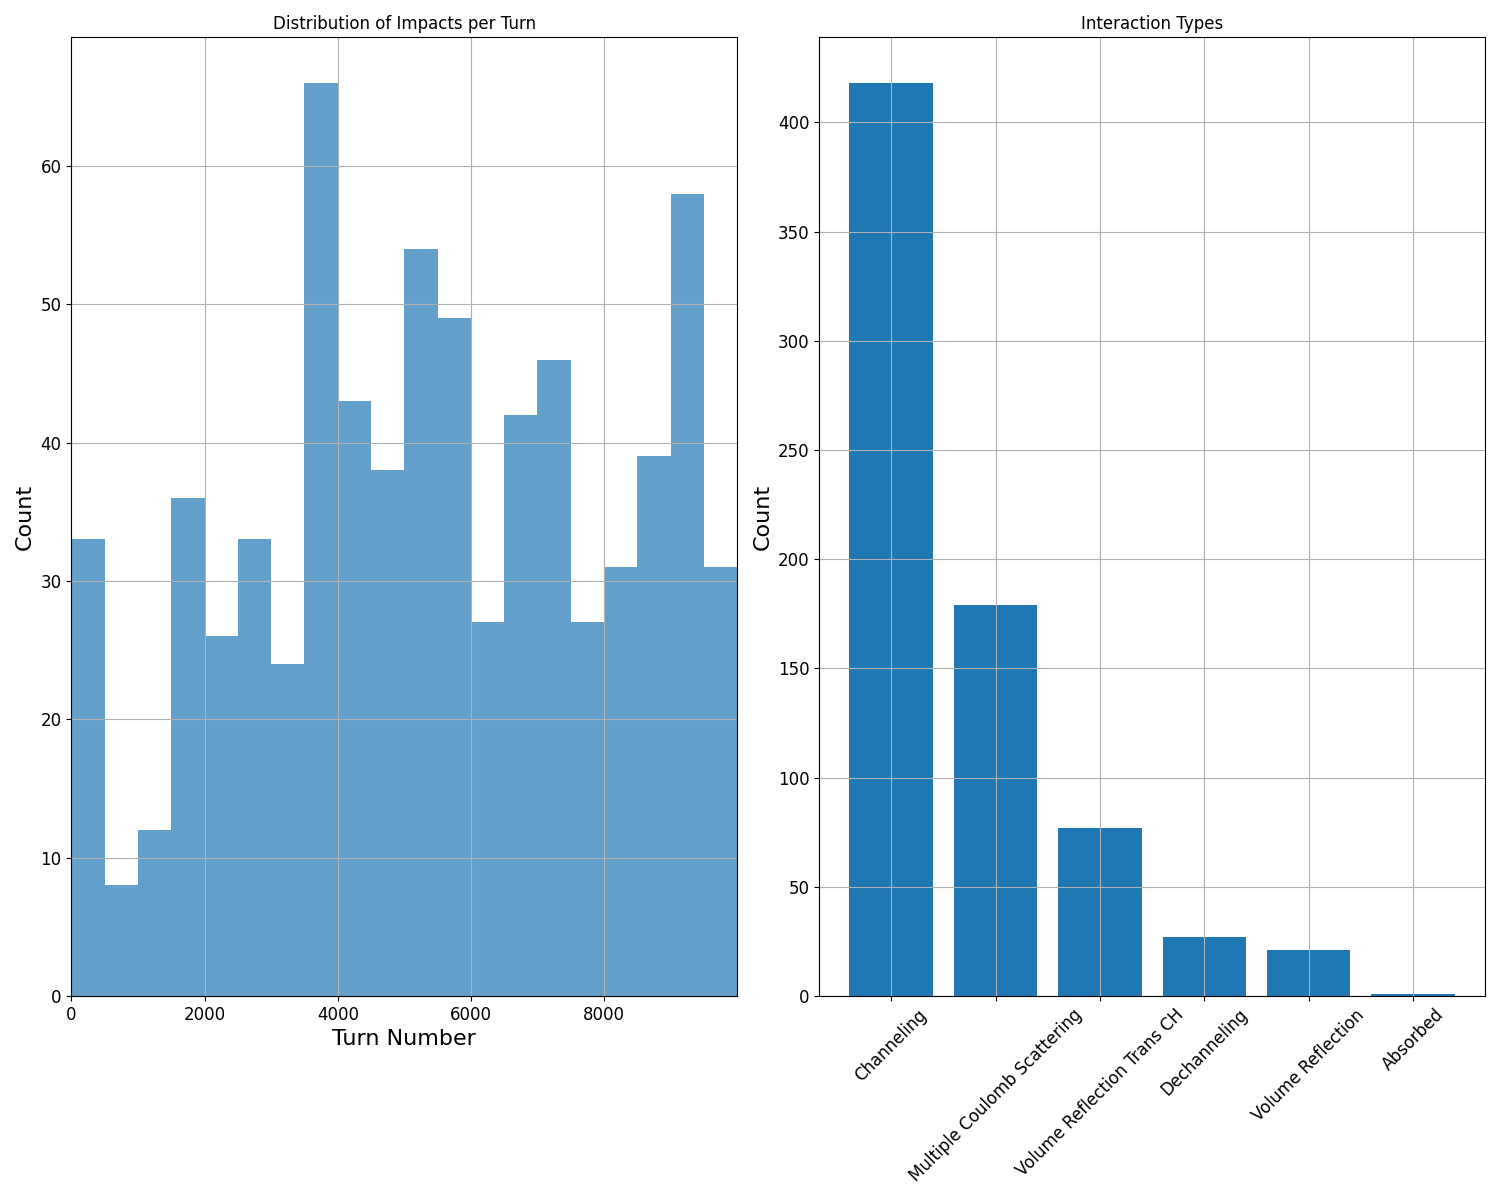


Summary Statistics:
Total number of impacts: 723
First impact at turn: 0
Last impact at turn: 9998

Interaction types distribution:
interaction_type
Channeling                     418
Multiple Coulomb Scattering    179
Volume Reflection Trans CH      77
Dechanneling                    27
Volume Reflection               21
Absorbed                         1
Name: count, dtype: int64


In [14]:
# First check if we have any impacts data
if df.empty:
    print("No impacts were recorded!")
else:
    # Create figure with multiple subplots
    fig, ((ax3, ax4)) = plt.subplots(1, 2, figsize=(15, 12))
    
    # # Plot 1: X-Y positions of impacts
    # if 'x' in df.columns and 'y' in df.columns:
    #     ax1.scatter(df['x'], df['y'], alpha=0.5, s=20)
    #     ax1.set_xlabel('x [m]')
    #     ax1.set_ylabel('y [m]')
    #     ax1.set_title('Impact Positions (x-y)')
    #     ax1.grid(True)
    
    # # Plot 2: X-PX phase space
    # if 'x' in df.columns and 'px' in df.columns:
    #     ax2.scatter(df['x'], df['px'], alpha=0.5, s=20)
    #     ax2.set_xlabel('x [m]')
    #     ax2.set_ylabel('px [rad]')
    #     ax2.set_title('Phase Space (x-px)')
    #     ax2.grid(True)
    
    # Plot 3: Turn number distribution
    if 'turn' in df.columns:
        ax3.hist(df['turn'], bins=20, alpha=0.7)
        ax3.set_xlabel('Turn Number')
        ax3.set_ylabel('Count')
        ax3.set_xlim(df['turn'].min(), df['turn'].max())
        ax3.set_title('Distribution of Impacts per Turn')
        ax3.grid(True)
    
    # Plot 4: Interaction types if available
    if 'interaction_type' in df.columns:
        interaction_counts = df['interaction_type'].value_counts()
        ax4.bar(range(len(interaction_counts)), interaction_counts.values)
        ax4.set_xticks(range(len(interaction_counts)))
        ax4.set_xticklabels(interaction_counts.index, rotation=45)
        ax4.set_ylabel('Count')
        ax4.set_title('Interaction Types')
        ax4.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\nSummary Statistics:")
    if 'turn' in df.columns:
        print(f"Total number of impacts: {len(df)}")
        print(f"First impact at turn: {df['turn'].min()}")
        print(f"Last impact at turn: {df['turn'].max()}")
    
    if 'interaction_type' in df.columns:
        print("\nInteraction types distribution:")
        print(df['interaction_type'].value_counts())

In [15]:
df

,turn,collimator_id,interaction_type,id_before,s_before,x_before,px_before,y_before,py_before,zeta_before,...,y_after,py_after,zeta_after,delta_after,energy_after,mass_after,charge_after,z_after,a_after,pdgid_after
0,0,2673,Multiple Coulomb Scattering,116,9.839998e-07,0.000396,-0.000014,5.957046e-22,-3.279091e-23,-0.012460,...,5.956392e-22,3.750927e-06,-0.012460,0.001278,4.011130e+11,9.382721e+08,1,-1,-1,-1
1,1,2673,Channeling,116,9.839998e-07,0.000200,-0.000007,1.472313e-04,-2.012908e-06,-0.033616,...,1.472273e-04,-2.012908e-06,-0.033616,0.001275,4.011119e+11,9.382721e+08,1,-1,-1,-1
2,1,2673,Channeling,428,9.839998e-07,0.000687,-0.000004,-5.068561e-22,-8.281706e-24,-0.039027,...,-5.068727e-22,-8.281706e-24,-0.039027,0.001474,4.011915e+11,9.382721e+08,1,-1,-1,-1
3,2,2673,Volume Reflection Trans CH,38,9.839998e-07,0.000717,-0.000007,-9.887844e-22,2.648090e-23,-0.056307,...,-9.887844e-22,2.648090e-23,-0.056307,0.001309,4.011252e+11,9.382721e+08,1,-1,-1,-1
4,2,2673,Multiple Coulomb Scattering,38,9.839998e-07,0.000717,-0.000008,-9.887844e-22,2.648090e-23,-0.056307,...,-9.887316e-22,-8.190927e-06,-0.056307,0.001309,4.011252e+11,9.382721e+08,1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,9942,2673,Multiple Coulomb Scattering,387,9.839998e-07,0.000798,-0.000007,1.096481e-22,2.097685e-23,-185.852299,...,1.096900e-22,-1.744807e-06,-185.852299,0.001879,4.007560e+11,9.382721e+08,1,-1,-1,-1
719,9943,2673,Channeling,387,9.839998e-07,0.000615,-0.000006,-6.804650e-05,9.087174e-07,-185.883731,...,-6.804469e-05,9.087174e-07,-185.883731,0.001876,4.007549e+11,9.382721e+08,1,-1,-1,-1
720,9972,2673,Channeling,424,9.839998e-07,0.000798,-0.000001,-7.562974e-22,2.053015e-24,-174.767943,...,-7.562933e-22,2.053015e-24,-174.767943,0.001813,4.007278e+11,9.382721e+08,1,-1,-1,-1
721,9994,2673,Channeling,188,9.839998e-07,0.000797,-0.000001,-9.973691e-22,2.583891e-23,-157.929179,...,-9.973175e-22,2.583891e-23,-157.929179,0.001714,4.006869e+11,9.382721e+08,1,-1,-1,-1


In [16]:
particles.to_pandas()

,particle_id,q0,_rng_s2,t_sim,x,start_tracking_at_element,weight,mass0,ax,_rng_s3,...,spin_y,pdg_id,parent_particle_id,delta,ptau,rvv,rpp,p0c,beta0,gamma0
0,379,1.0,4287432232,0.000023,0.012732,-1,1.0,9.382721e+08,0.0,1320398659,...,0.0,0,379,0.001901,0.001901,1.0,0.998103,4.000000e+11,0.999997,426.316743
1,282,1.0,2203185548,0.000023,0.010301,-1,1.0,9.382721e+08,0.0,2349333166,...,0.0,0,282,0.001587,0.001587,1.0,0.998416,4.000000e+11,0.999997,426.316743
2,2,1.0,3435155199,0.000023,0.010745,-1,1.0,9.382721e+08,0.0,552542498,...,0.0,0,2,0.001652,0.001652,1.0,0.998351,4.000000e+11,0.999997,426.316743
3,266,1.0,2452558446,0.000023,0.010511,-1,1.0,9.382721e+08,0.0,2573665653,...,0.0,0,266,0.001615,0.001615,1.0,0.998387,4.000000e+11,0.999997,426.316743
4,174,1.0,730054644,0.000023,0.012793,-1,1.0,9.382721e+08,0.0,3990416072,...,0.0,0,174,0.001963,0.001963,1.0,0.998041,4.000000e+11,0.999997,426.316743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,215,1.0,1762324518,0.000023,0.170706,-1,1.0,9.382721e+08,0.0,727346583,...,0.0,0,215,0.001408,0.001408,1.0,0.998594,4.005997e+11,0.999997,426.955895
496,330,1.0,561156509,0.000023,0.171132,-1,1.0,9.382721e+08,0.0,29727632,...,0.0,0,330,0.001400,0.001400,1.0,0.998602,4.005998e+11,0.999997,426.955959
497,432,1.0,823087495,0.000023,0.170724,-1,1.0,9.382721e+08,0.0,1046994508,...,0.0,0,432,0.001401,0.001401,1.0,0.998601,4.005998e+11,0.999997,426.956023
498,428,1.0,3830737451,0.000023,0.170376,-1,1.0,9.382721e+08,0.0,4185718979,...,0.0,0,428,0.001473,0.001473,1.0,0.998530,4.005999e+11,0.999997,426.956086


In [17]:
p = particles.to_pandas()[['particle_id', 'state', 'at_element']]
p.index = p.particle_id
p['lost_at'] = [line.element_names[particles.at_element[idx]] for idx in p.particle_id]
p

,particle_id,state,at_element,lost_at
particle_id,,,,
379,379,1,0,tt20.extraction
282,282,1,0,tt20.extraction
2,2,1,0,sps$start
266,266,1,0,tt20.extraction
174,174,1,0,tt20.extraction
...,...,...,...,...
215,215,0,1202,tt20.extraction
330,330,0,1202,tt20.extraction
432,432,0,1202,tt20.extraction


In [18]:
df

,turn,collimator_id,interaction_type,id_before,s_before,x_before,px_before,y_before,py_before,zeta_before,...,y_after,py_after,zeta_after,delta_after,energy_after,mass_after,charge_after,z_after,a_after,pdgid_after
0,0,2673,Multiple Coulomb Scattering,116,9.839998e-07,0.000396,-0.000014,5.957046e-22,-3.279091e-23,-0.012460,...,5.956392e-22,3.750927e-06,-0.012460,0.001278,4.011130e+11,9.382721e+08,1,-1,-1,-1
1,1,2673,Channeling,116,9.839998e-07,0.000200,-0.000007,1.472313e-04,-2.012908e-06,-0.033616,...,1.472273e-04,-2.012908e-06,-0.033616,0.001275,4.011119e+11,9.382721e+08,1,-1,-1,-1
2,1,2673,Channeling,428,9.839998e-07,0.000687,-0.000004,-5.068561e-22,-8.281706e-24,-0.039027,...,-5.068727e-22,-8.281706e-24,-0.039027,0.001474,4.011915e+11,9.382721e+08,1,-1,-1,-1
3,2,2673,Volume Reflection Trans CH,38,9.839998e-07,0.000717,-0.000007,-9.887844e-22,2.648090e-23,-0.056307,...,-9.887844e-22,2.648090e-23,-0.056307,0.001309,4.011252e+11,9.382721e+08,1,-1,-1,-1
4,2,2673,Multiple Coulomb Scattering,38,9.839998e-07,0.000717,-0.000008,-9.887844e-22,2.648090e-23,-0.056307,...,-9.887316e-22,-8.190927e-06,-0.056307,0.001309,4.011252e+11,9.382721e+08,1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,9942,2673,Multiple Coulomb Scattering,387,9.839998e-07,0.000798,-0.000007,1.096481e-22,2.097685e-23,-185.852299,...,1.096900e-22,-1.744807e-06,-185.852299,0.001879,4.007560e+11,9.382721e+08,1,-1,-1,-1
719,9943,2673,Channeling,387,9.839998e-07,0.000615,-0.000006,-6.804650e-05,9.087174e-07,-185.883731,...,-6.804469e-05,9.087174e-07,-185.883731,0.001876,4.007549e+11,9.382721e+08,1,-1,-1,-1
720,9972,2673,Channeling,424,9.839998e-07,0.000798,-0.000001,-7.562974e-22,2.053015e-24,-174.767943,...,-7.562933e-22,2.053015e-24,-174.767943,0.001813,4.007278e+11,9.382721e+08,1,-1,-1,-1
721,9994,2673,Channeling,188,9.839998e-07,0.000797,-0.000001,-9.973691e-22,2.583891e-23,-157.929179,...,-9.973175e-22,2.583891e-23,-157.929179,0.001714,4.006869e+11,9.382721e+08,1,-1,-1,-1


In [19]:
df1 = df[['turn', 'interaction_type', 'id_before']].copy()
df1.index = df1['id_before']

In [20]:
df2 = df1.join(p, how='inner')
df2

,turn,interaction_type,id_before,particle_id,state,at_element,lost_at
id_before,,,,,,,
116,0,Multiple Coulomb Scattering,116,116,0,1202,tt20.extraction
116,1,Channeling,116,116,0,1202,tt20.extraction
428,1,Channeling,428,428,0,1202,tt20.extraction
38,2,Volume Reflection Trans CH,38,38,0,1202,sps$start
38,2,Multiple Coulomb Scattering,38,38,0,1202,sps$start
...,...,...,...,...,...,...,...
387,9942,Multiple Coulomb Scattering,387,387,0,1202,tt20.extraction
387,9943,Channeling,387,387,0,1202,tt20.extraction
424,9972,Channeling,424,424,0,1202,tt20.extraction


In [21]:
df2.plot?

Signature:      df2.plot(*args, **kwargs)
Type:           PlotAccessor
String form:    <pandas.plotting._core.PlotAccessor object at 0x11852fdd0>
File:           ~/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/pandas/plotting/_core.py
Docstring:     
Make plots of Series or DataFrame.

Uses the backend specified by the
option ``plotting.backend``. By default, matplotlib is used.

Parameters
----------
data : Series or DataFrame
    The object for which the method is called.
x : label or position, default None
    Only used if data is a DataFrame.
y : label, position or list of label, positions, default None
    Allows plotting of one column versus another. Only used if data is a
    DataFrame.
kind : str
    The kind of plot to produce:

    - 'line' : line plot (default)
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Estimation plot
    - 'density' : same as 'kde'
    - 'area' : a

In [22]:
extr = df2[df2.state == 0].groupby(['turn']).particle_id.count()
lost = df2[df2.state == -1].groupby(['turn']).particle_id.count()

In [23]:
extr.loc[2]

np.int64(3)

In [24]:
d =dict(
    extracted = [],
    lost = [],
)
for i in range(num_turns):
    try:
        extracted = extr.loc[i]
    except:
        extracted = 0
    
    try:
        lost = lost.loc[i]
    except:
        lost = 0
    d['extracted'].append(extracted)
    d['lost'].append(lost)
    
df3 = pd.DataFrame(d, index=range(num_turns))
df3

,extracted,lost
0,1,0
1,2,0
2,3,0
3,1,0
4,2,0
...,...,...
9995,0,0
9996,0,0
9997,0,0
9998,1,0


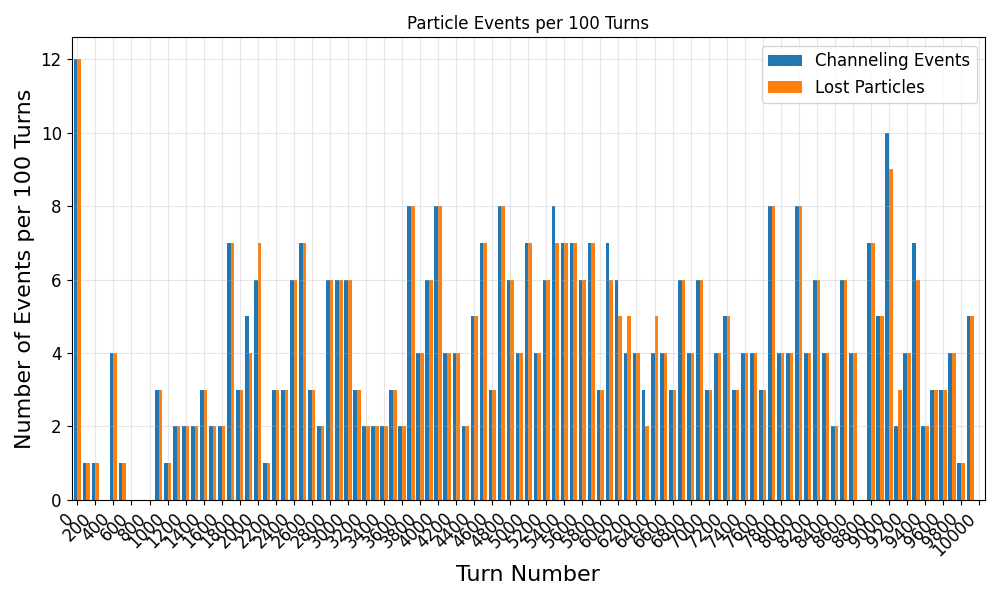

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create bins of 100 turns
bin_size = 100
n_bins = num_turns // bin_size + 1  # Add 1 to include any remaining turns
bins = np.arange(0, (n_bins + 1) * bin_size, bin_size)

# Aggregate data for channeling events
channeling_df = df[df['interaction_type'] == "Channeling"]
channeling_data = np.zeros(n_bins)
for i in channeling_df['turn']:
    bin_index = i // bin_size
    if bin_index < n_bins:  # Ensure we don't exceed array bounds
        channeling_data[bin_index] += 1

# Aggregate data for lost particles
lost_particles = np.where(particles.state < 1)[0]
lost_data = np.zeros(n_bins)
for idx in lost_particles:
    turn = particles.at_turn[idx]
    bin_index = turn // bin_size
    if bin_index < n_bins:  # Ensure we don't exceed array bounds
        lost_data[bin_index] += 1

# Create DataFrame with the binned data
df_binned = pd.DataFrame({
    'channeling': channeling_data,
    'lost': lost_data
}, index=bins[:-1])

# Plot
df_binned.plot(kind='bar', ax=ax, width=0.8)

plt.xlabel('Turn Number')
plt.ylabel('Number of Events per 100 Turns')
plt.title('Particle Events per 100 Turns')
plt.legend(['Channeling Events', 'Lost Particles'])
plt.grid(True, alpha=0.3)

# Show every Nth label for better readability
N = 2  # Adjust this value to show more or fewer labels
plt.xticks(range(0, len(bins)-1, N), bins[:-1:N], rotation=45, ha='right')

plt.tight_layout()

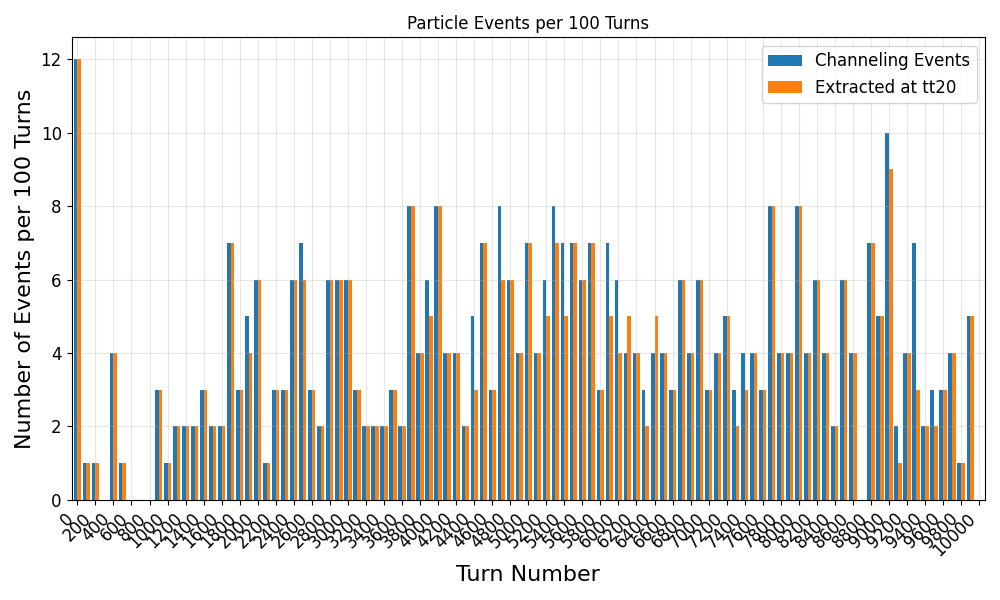

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create bins of 100 turns
bin_size = 100
n_bins = num_turns // bin_size + 1  # Add 1 to include any remaining turns
bins = np.arange(0, (n_bins + 1) * bin_size, bin_size)

# Aggregate data for channeling events
channeling_df = df[df['interaction_type'] == "Channeling"]
channeling_data = np.zeros(n_bins)
for i in channeling_df['turn']:
    bin_index = i // bin_size
    if bin_index < n_bins:  # Ensure we don't exceed array bounds
        channeling_data[bin_index] += 1

# Aggregate data for lost particles
lost_particles = np.where(particles.state < 1)[0]
lost_data = np.zeros(n_bins)
for idx in lost_particles:
    turn = particles.at_turn[idx]
    bin_index = turn // bin_size
    if bin_index < n_bins:  # Ensure we don't exceed array bounds
        lost_data[bin_index] += 1

# Aggregate data for particles lost at tt20.extraction
lost_at_tt20 = [idx for idx in lost_particles if line.element_names[particles.at_element[idx]] == 'tt20.extraction']
tt20_data = np.zeros(n_bins)
for idx in lost_at_tt20:
    turn = particles.at_turn[idx]
    bin_index = turn // bin_size
    if bin_index < n_bins:  # Ensure we don't exceed array bounds
        tt20_data[bin_index] += 1


# Create DataFrame with the binned data
df_binned = pd.DataFrame({
    'channeling': channeling_data,
    #'lost': lost_data,
    'extracted': tt20_data
}, index=bins[:-1])

# Plot
df_binned.plot(kind='bar', ax=ax, width=0.8)

plt.xlabel('Turn Number')
plt.ylabel('Number of Events per 100 Turns')
plt.title('Particle Events per 100 Turns')
plt.legend(['Channeling Events', 'Extracted at tt20'])
plt.grid(True, alpha=0.3)

# Show every Nth label for better readability
N = 2  # Adjust this value to show more or fewer labels
plt.xticks(range(0, len(bins)-1, N), bins[:-1:N], rotation=45, ha='right')

plt.tight_layout()

<Axes: ylabel='Frequency'>

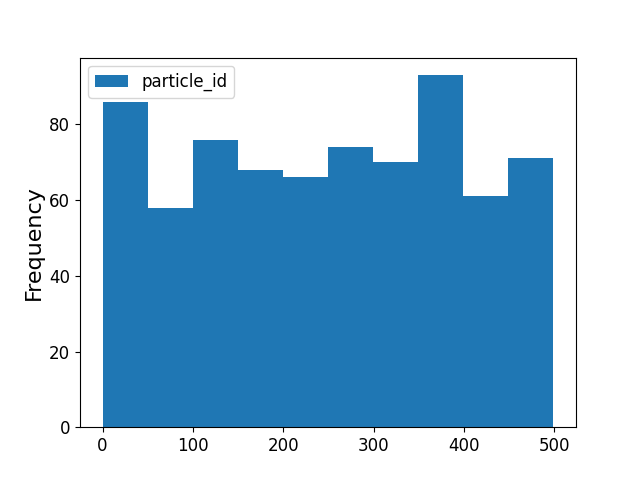

In [27]:
df2.plot(kind='hist', x='turn', y='particle_id')

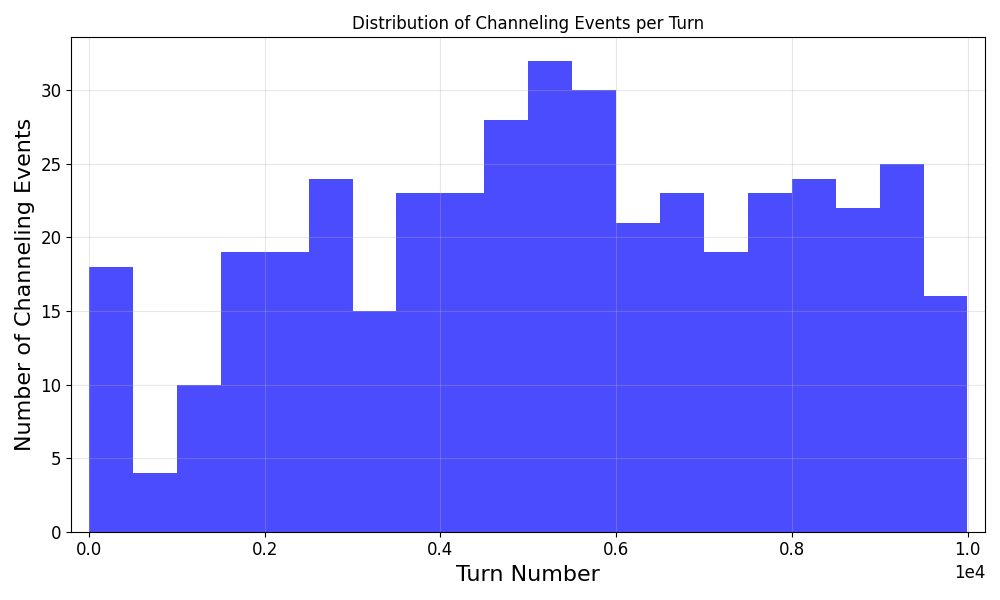

In [28]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

# Create histogram for turns where interaction_type is channeling (value=1)
channeling_df = df[df['interaction_type'] == "Channeling"]
plt.hist(channeling_df['turn'], bins=20, color='blue', alpha=0.7)

# Customize the plot
plt.xlabel('Turn Number')
plt.ylabel('Number of Channeling Events')
plt.title('Distribution of Channeling Events per Turn')
plt.grid(True, alpha=0.3)

# Add some padding to the axes
plt.margins(x=0.02)

# Tight layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [29]:
# Add before tracking
print("Tracking setup verification:")
print(f"TECA recording enabled: {TECA.record_scatterings}")
print(f"IO buffer capacity: {io_buffer.capacity}")

# Check if TECA is in the logged elements (use .elements, not ._elements)
teca_in_logged = any(
	getattr(el, "name", None) == "extraction.crystal.TECA"
	for el in getattr(impacts, "elements", [])
)
print(f"TECA in logged elements: {teca_in_logged}")

Tracking setup verification:
TECA recording enabled: True
IO buffer capacity: 2490000816
TECA in logged elements: False


In [30]:
import numpy as np

# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

if len(lost_particles) > 0:
    print(f"Number of lost particles: {len(lost_particles)}")
    print("\nParticle loss locations:")

    # Get element names from the line
    element_names = line.element_names

    # Count losses per element
    loss_counts = {}
    for idx in lost_particles:
        lost_at = particles.at_element[idx]  # Index of element where the particle was lost
        lost_element_name = element_names[lost_at]
        loss_counts[lost_element_name] = loss_counts.get(lost_element_name, 0) + 1

    # Print where the particles were lost
    for element, count in loss_counts.items():
        print(f"{count} particles lost at element '{element}'")
else:
    print("No particles were lost during tracking")
    
# Calculate extraction efficiency: particles lost at 'tt20' / total number of particles

# Find indices of lost particles at 'tt20'
lost_at_tt20 = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tt20.extraction'
]

n_lost_tt20 = len(lost_at_tt20)
n_total = particles_init._capacity

if n_total > 0:
    efficiency = n_lost_tt20 / n_total
    print(f"Extraction efficiency at 'tt20': {efficiency:.4%} ({n_lost_tt20}/{n_total})")
else:
    print("No particles in the initial distribution.")

Number of lost particles: 415

Particle loss locations:
395 particles lost at element 'tt20.extraction'
19 particles lost at element 'tpst.21760_entry.sep'
1 particles lost at element 'extraction.crystal.TECA'
Extraction efficiency at 'tt20': 79.0000% (395/500)


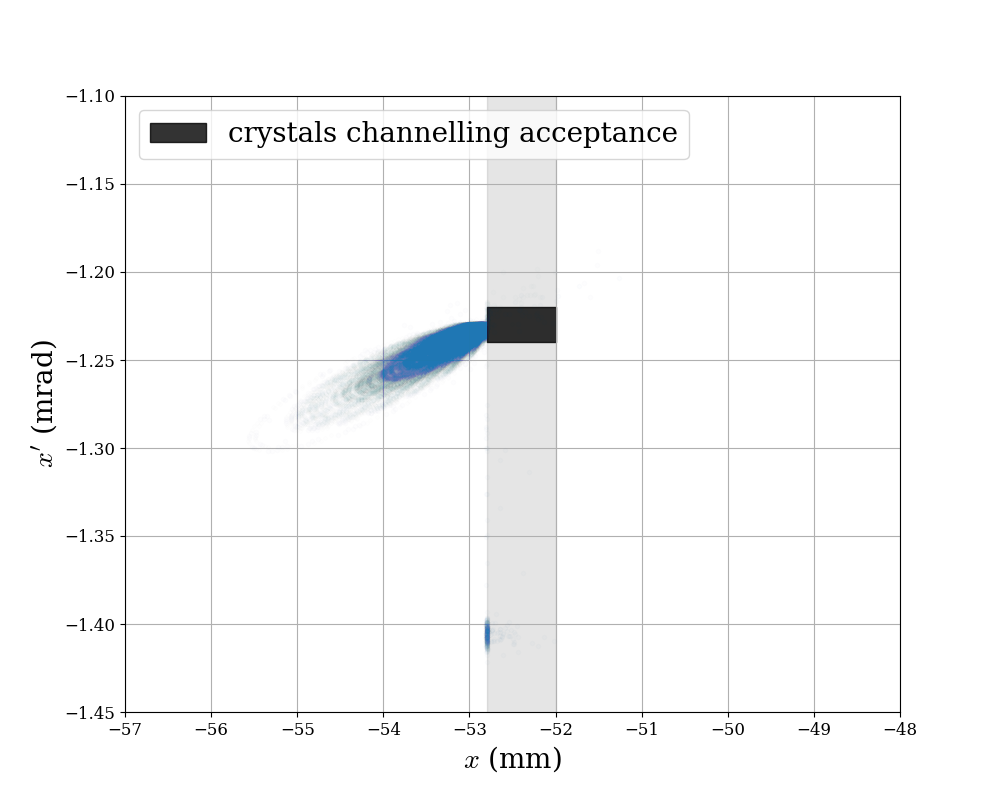

In [31]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    alpha_val = (turn + 1) / num_turns  # alpha increases from 0 to 1
    ax.plot(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,
        row_TECA_exit['monitors'].px[:, turn] * 1e3,
        '.', 
        color='C0',
        alpha=alpha_val
    ) 

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.8, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -100, +100, color='k', alpha=0.1)

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(-57, -48)
ax.set_ylim(-1.45, -1.1)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

In [32]:
# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

if len(lost_particles) > 0:
    print(f"Total number of lost particles: {len(lost_particles)}")
    print("\nLost particle details:")
    for idx in lost_particles:
        element_name = line.element_names[particles.at_element[idx]]
        turn_number = particles.at_turn[idx]
        print(f"Particle {idx}: lost at turn {turn_number} in element '{element_name}'")
    
    # Calculate statistics
    turn_stats = np.array([particles.at_turn[idx] for idx in lost_particles])
    print(f"\nTurn loss statistics:")
    print(f"Mean turn of loss: {np.mean(turn_stats):.1f}")
    print(f"Min turn of loss: {np.min(turn_stats)}")
    print(f"Max turn of loss: {np.max(turn_stats)}")
else:
    print("No particles were lost during tracking")

Total number of lost particles: 415

Lost particle details:
Particle 85: lost at turn 9999 in element 'tt20.extraction'
Particle 86: lost at turn 9995 in element 'tt20.extraction'
Particle 87: lost at turn 9973 in element 'tt20.extraction'
Particle 88: lost at turn 9944 in element 'tt20.extraction'
Particle 89: lost at turn 9920 in element 'tt20.extraction'
Particle 90: lost at turn 9869 in element 'tt20.extraction'
Particle 91: lost at turn 9785 in element 'tt20.extraction'
Particle 92: lost at turn 9760 in element 'tt20.extraction'
Particle 93: lost at turn 9759 in element 'tt20.extraction'
Particle 94: lost at turn 9728 in element 'tt20.extraction'
Particle 95: lost at turn 9696 in element 'tt20.extraction'
Particle 96: lost at turn 9657 in element 'tt20.extraction'
Particle 97: lost at turn 9614 in element 'tt20.extraction'
Particle 98: lost at turn 9595 in element 'tt20.extraction'
Particle 99: lost at turn 9594 in element 'tt20.extraction'
Particle 100: lost at turn 9534 in eleme

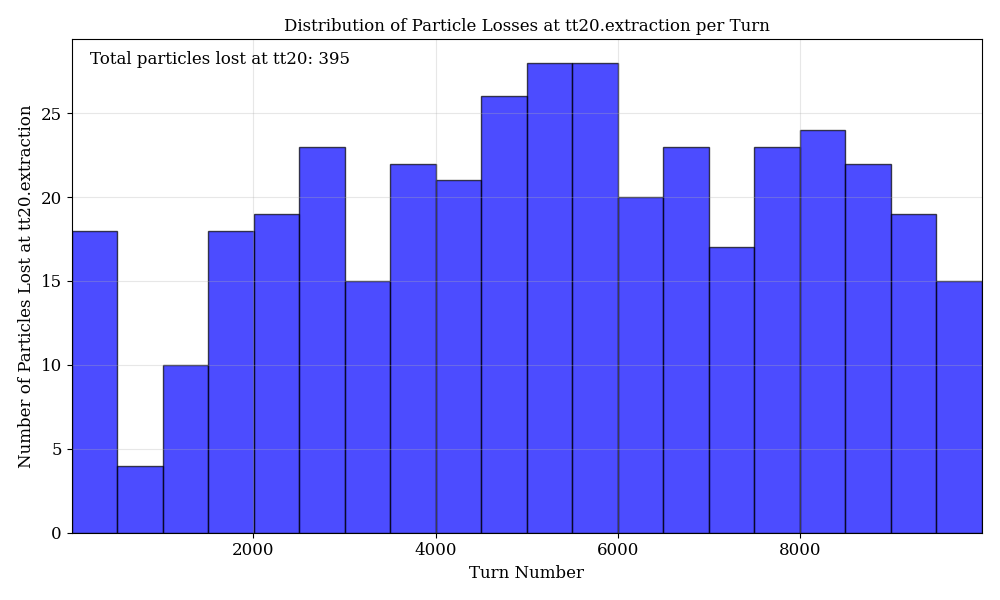

In [33]:
# Get indices of particles lost at tt20.extraction
lost_at_tt20 = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tt20.extraction'
]

# Get the turn numbers where particles were lost at tt20
turn_numbers = [particles.at_turn[idx] for idx in lost_at_tt20]

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(turn_numbers, bins=20, color='blue', alpha=0.7, edgecolor='black')

# Customize the plot
plt.xlabel('Turn Number')
plt.ylabel('Number of Particles Lost at tt20.extraction')
plt.title('Distribution of Particle Losses at tt20.extraction per Turn')
plt.grid(True, alpha=0.3)
plt.xlim(min(turn_numbers), max(turn_numbers))

# Add text with statistics
plt.text(0.02, 0.95, f'Total particles lost at tt20: {len(lost_at_tt20)}', 
         transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

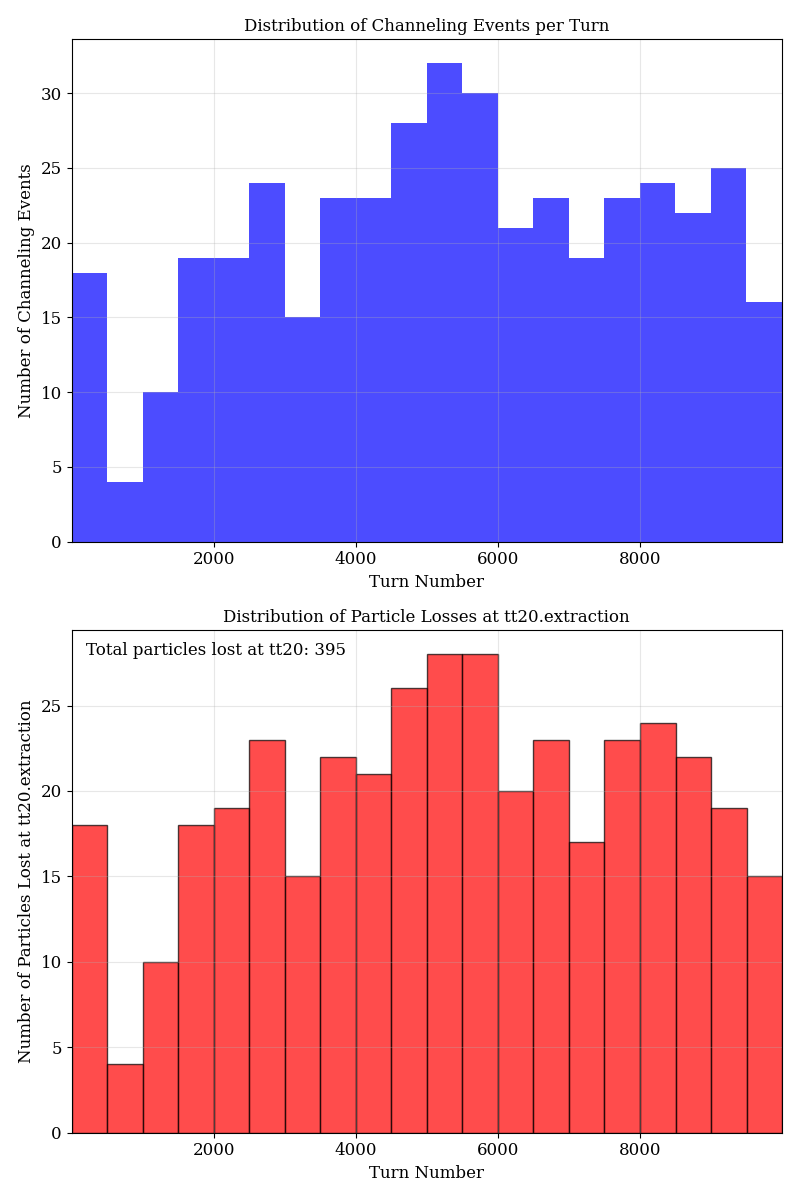

In [34]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))

# Plot 1: Channeling events histogram
channeling_df = df[df['interaction_type'] == "Channeling"]
ax1.hist(channeling_df['turn'], bins=20, color='blue', alpha=0.7)
ax1.set_xlabel('Turn Number')
ax1.set_ylabel('Number of Channeling Events')
ax1.set_title('Distribution of Channeling Events per Turn')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(channeling_df['turn'].min(), channeling_df['turn'].max())

# Plot 2: Particles lost at tt20 histogram
lost_at_tt20 = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tt20.extraction'
]
turn_numbers = [particles.at_turn[idx] for idx in lost_at_tt20]

ax2.hist(turn_numbers, bins=20, color='red', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Turn Number')
ax2.set_ylabel('Number of Particles Lost at tt20.extraction')
ax2.set_title('Distribution of Particle Losses at tt20.extraction')
ax2.grid(True, alpha=0.3)
ax2.text(0.02, 0.95, f'Total particles lost at tt20: {len(lost_at_tt20)}', 
         transform=ax2.transAxes)
ax2.set_xlim(channeling_df['turn'].min(), channeling_df['turn'].max())


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


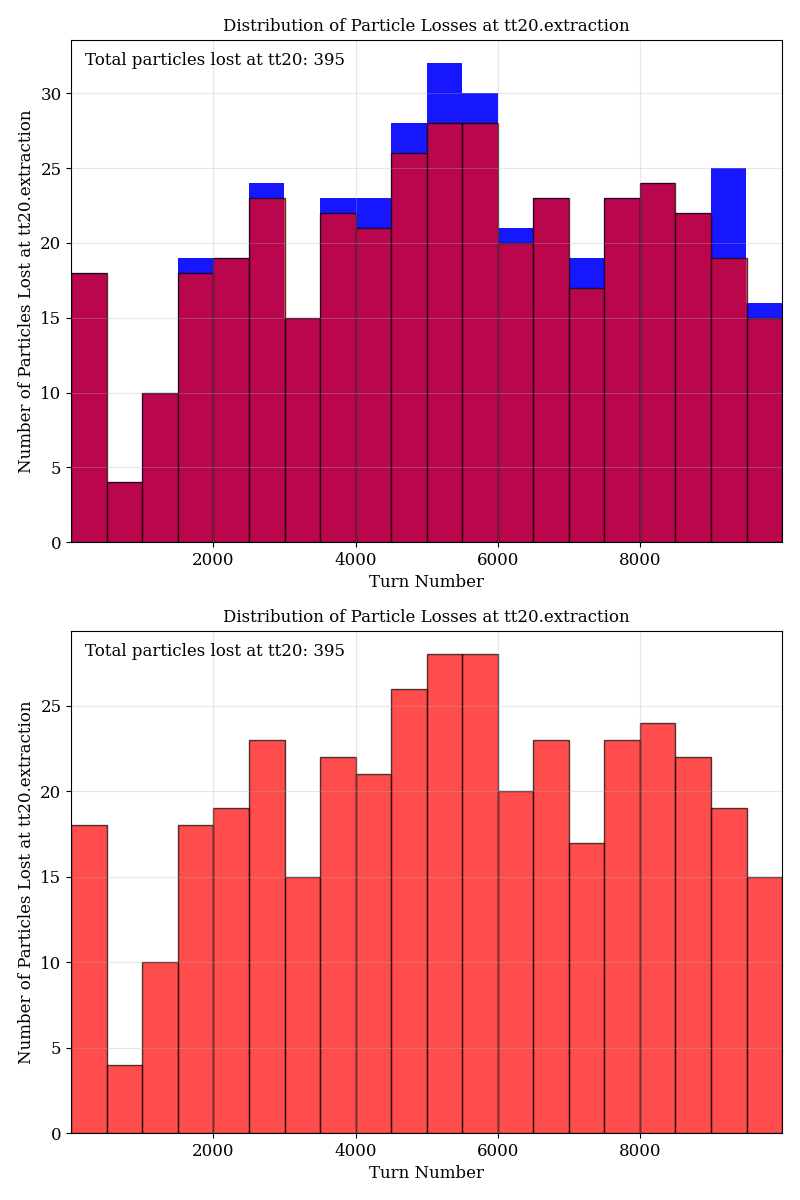

In [35]:
# Plot 1: Channeling events histogram
channeling_df = df[df['interaction_type'] == "Channeling"]
ax1.hist(channeling_df['turn'], bins=20, color='blue', alpha=0.7)
ax1.set_xlabel('Turn Number')
ax1.set_ylabel('Number of Channeling Events')
ax1.set_title('Distribution of Channeling Events per Turn')
ax1.set_xlim(channeling_df['turn'].min(), channeling_df['turn'].max())

# Plot 2: Particles lost at tt20 histogram
lost_at_tt20 = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tt20.extraction'
]
turn_numbers = [particles.at_turn[idx] for idx in lost_at_tt20]

ax1.hist(turn_numbers, bins=20, color='red', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Turn Number')
ax1.set_ylabel('Number of Particles Lost at tt20.extraction')
ax1.set_title('Distribution of Particle Losses at tt20.extraction')
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.95, f'Total particles lost at tt20: {len(lost_at_tt20)}', 
         transform=ax1.transAxes)
ax1.set_xlim(channeling_df['turn'].min(), channeling_df['turn'].max())

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# USED IT WITH PANDAS

# Animation of the spill

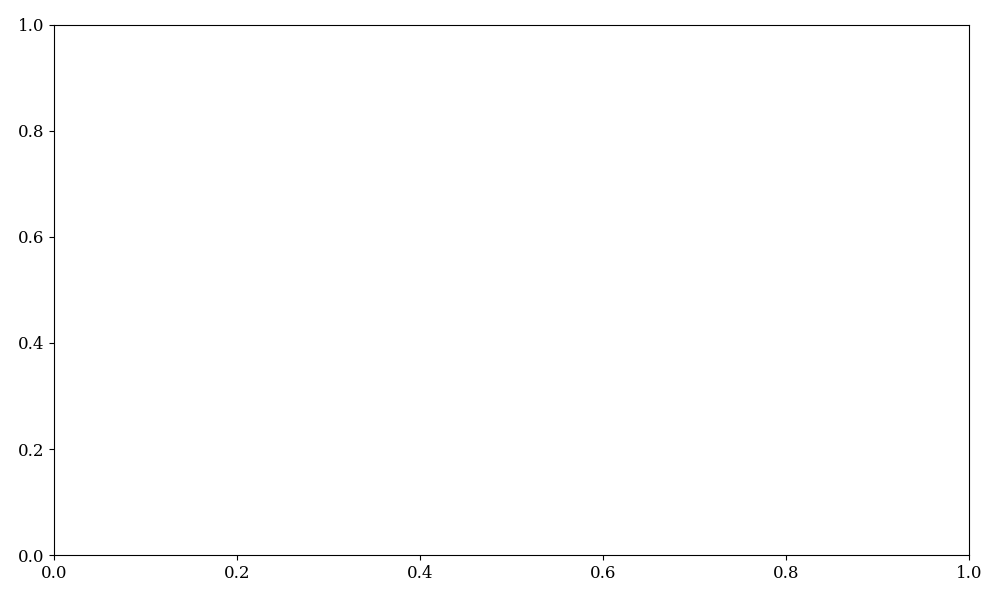

In [36]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Prepare the data
channeling_df = df[df['interaction_type'] == "Channeling"]
turn_data = channeling_df['turn'].values
unique_turns = np.sort(np.unique(turn_data))

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate the maximum count for consistent y-axis scaling
hist_full, _ = np.histogram(turn_data, bins=unique_turns.size, range=(unique_turns.min(), unique_turns.max() + 1))
max_count = hist_full.max()

# Animation update function
def update(frame):
    ax.clear()
    # Only include bins up to the current frame (turn)
    bins = unique_turns[:frame + 1]
    if len(bins) > 1:
        counts, _ = np.histogram(turn_data, bins=np.append(bins, bins[-1] + 1))
        ax.bar(bins, counts, width=1, color='blue', alpha=0.7, edgecolor='black')
        ax.set_xlim(unique_turns.min() - 1, unique_turns.max() + 1)
        ax.set_ylim(0, 10)
        ax.set_xlabel('Turn Number')
        ax.set_ylabel('Number of Channeling Events')
        ax.set_title(f'Channeling Events Histogram: {bins[0]} to {bins[-1]}')
        ax.grid(True, alpha=0.3)

# Create animation: one frame per unique turn
anim = animation.FuncAnimation(
    fig, update, frames=len(unique_turns), interval=100, repeat=False
)

plt.tight_layout()
plt.show()


# FIXBIN OPTION